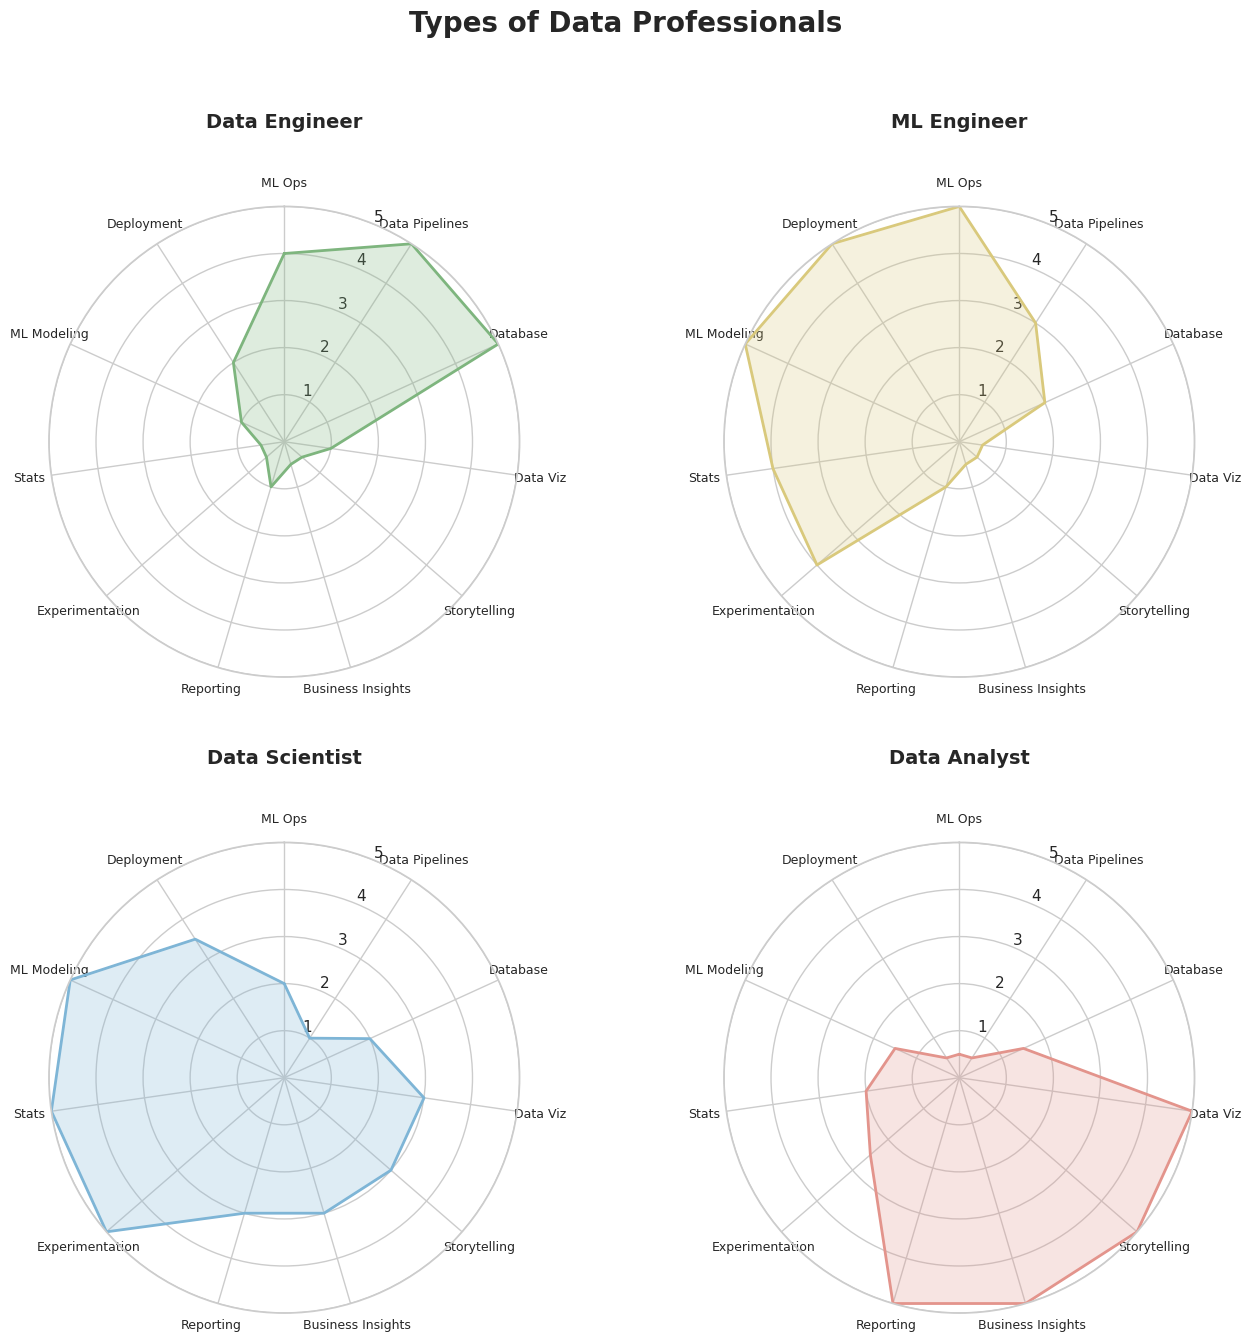

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

def draw_radar_chart(ax, categories, values, title, color):
    """
    Draws a single radar chart on a provided Matplotlib Axes object.
    """
    num_vars = len(categories)
    
    # Calculate angles for 11 variables
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    # Close the loop
    values_closed = values + [values[0]]
    angles_closed = angles + [angles[0]]
    
    # Plot data and fill area
    ax.plot(angles_closed, values_closed, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles_closed, values_closed, color=color, alpha=0.25)
    
    # Format the polar orientation
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Set labels and limits
    ax.set_thetagrids(np.degrees(angles), categories, fontsize=9)
    ax.set_ylim(0, 5)
    
    # Set the title
    ax.set_title(title, y=1.15, fontsize=14, fontweight='bold')

# --- Execution Example ---

import pandas as pd

# 1. Define the 11 categories shown in the image
categories = [
    'ML Ops', 'Data Pipelines', 'Database', 'Data Viz', 
    'Storytelling', 'Business Insights', 'Reporting', 
    'Experimentation', 'Stats', 'ML Modeling', 'Deployment'
]

# 2. Define skill ratings for each data professional as a dataframe for easy editing
data_professionals_df = pd.DataFrame({
    'Role': [
        'Data Engineer',
        'ML Engineer',
        'Data Scientist',
        'Data Analyst'
    ],
    'Color': [
        '#7eb57e',   # Green
        '#d9c97c',   # Yellow
        '#7eb5d6',   # Blue
        '#e3948c'    # Red
    ],
    'ML Ops':            [  4,   5,   2, 0.5],
    'Data Pipelines':    [  5,   3,   1, 0.5],
    'Database':          [  5,   2,   2, 1.5],
    'Data Viz':          [  1, 0.5,   3, 5],
    'Storytelling':      [0.5, 0.5,   3, 5],
    'Business Insights': [0.5, 0.5,   3, 5],
    'Reporting':         [  1,   1,   3, 5],
    'Experimentation':   [0.5,   4,   5, 2.5],
    'Stats':             [0.5,   4,   5, 2],
    'ML Modeling':       [  1,   5,   5, 1.5],
    'Deployment':        [  2,   5, 3.5, 0.5],
})

# 3. Initialize a 2x2 grid with polar projections
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 14), subplot_kw=dict(polar=True))
axes_flat = axes.flatten()

# 4. Plot each professional
for i, row in data_professionals_df.iterrows():
    values = [row[cat] for cat in categories]
    color = row['Color']
    title = row['Role']
    draw_radar_chart(ax=axes_flat[i], categories=categories, values=values, title=title, color=color)

fig.suptitle("Types of Data Professionals", fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(pad=3.0)
plt.show()

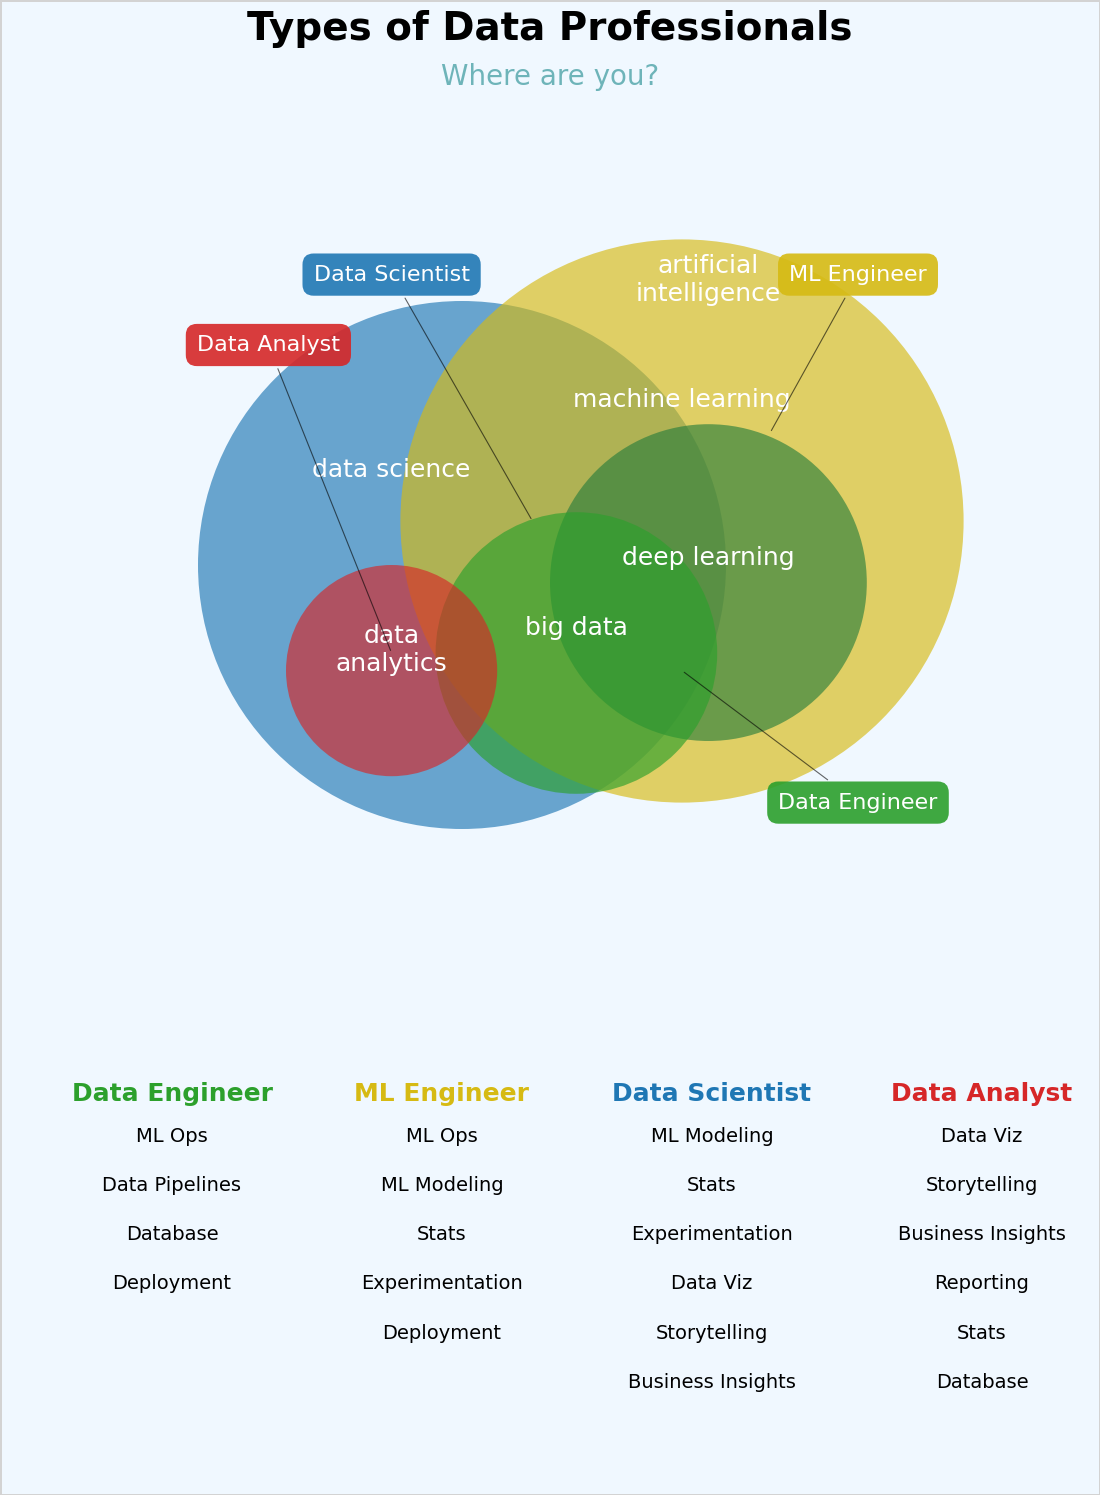

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties
import numpy as np

# --- 1. CONFIGURATION AND STYLING ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']  # Standard accessible fonts

# Colors from the image
COLOR_DS = (31/255, 119/255, 180/255)      # Blue (Data Science)
COLOR_ML = (214/255, 186/255, 19/255)      # Yellow (Machine Learning)
COLOR_DE = (44/255, 160/255, 44/255)       # Green (Big Data/Data Engineer)
COLOR_DA = (214/255, 39/255, 40/255)       # Red (Data Analytics)
COLOR_DL = (44/255, 127/255, 60/255)       # Darker Green for DL/Nested

COLOR_BG = (240/255, 248/255, 255/255)     # Very light background
COLOR_TEXT_LIGHT = (110/255, 180/255, 185/255) # Subtitle color

# Opacity for diagram sets
ALPHA = 0.65

# --- 2. SETUP FIGURE ---
fig = plt.figure(figsize=(12, 16), dpi=100)
# Outer border and background color
fig.patch.set_facecolor(COLOR_BG)
fig.patch.set_edgecolor('lightgrey')
fig.patch.set_linewidth(1)

# Main Titles
fig.text(0.5, 0.96, "Types of Data Professionals", 
         ha='center', va='center', fontsize=28, fontweight='bold', color='black')
fig.text(0.5, 0.93, "Where are you?", 
         ha='center', va='center', fontsize=20, color=COLOR_TEXT_LIGHT)

# Ax for the main diagram (relative coordinates: x, y, width, height)
ax = fig.add_axes([0.05, 0.35, 0.9, 0.55], aspect='equal')
ax.set_axis_off()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)


# --- 3. DRAW THE EULER DIAGRAM SETS ---
# Define precise locations to recreate the complex overlaps

# A. Data Science (Main set on the left)
ds_circle = mpatches.Circle((40, 50), 30, facecolor=COLOR_DS, alpha=ALPHA, edgecolor='none')
ax.add_patch(ds_circle)
ax.text(32, 60, "data science", ha='center', fontsize=18, color='white')

# B. Machine Learning (Main set on the right, overlapping DS)
ml_circle = mpatches.Circle((65, 55), 32, facecolor=COLOR_ML, alpha=ALPHA, edgecolor='none')
ax.add_patch(ml_circle)
# Label for AI and ML within the ML circle
ax.text(68, 80, "artificial\nintelligence", ha='center', fontsize=18, color='white', fontweight='normal')
ax.text(65, 68, "machine learning", ha='center', fontsize=18, color='white')

# C. Big Data / Deep Learning complex overlap
# This part requires specialized positioning.
# Deep learning is nested in ML.
dl_circle = mpatches.Circle((68, 48), 18, facecolor=COLOR_DL, alpha=ALPHA, edgecolor='none')
ax.add_patch(dl_circle)
ax.text(68, 50, "deep learning", ha='center', fontsize=18, color='white')

# D. Big Data / Data Engineering (overlapping both main sets and DL)
de_circle = mpatches.Circle((53, 40), 16, facecolor=COLOR_DE, alpha=ALPHA, edgecolor='none')
ax.add_patch(de_circle)
ax.text(53, 42, "big data", ha='center', fontsize=18, color='white')

# E. Data Analytics (smaller set within Data Science and Big Data)
da_circle = mpatches.Circle((32, 38), 12, facecolor=COLOR_DA, alpha=ALPHA, edgecolor='none')
ax.add_patch(da_circle)
ax.text(32, 38, "data\nanalytics", ha='center', fontsize=18, color='white')


# --- 4. ADD CALLOUTS (ANNOTATIONS) FOR THE 4 ROLES ---

# Role properties for clean boxes
arrow_prop = dict(arrowstyle='-', color='black', alpha=0.6, linewidth=0.8)

# Callout function for consistency
def add_role_callout(ax, xy_start, xy_text, text, color):
    ax.annotate(text, xy=xy_start, xytext=xy_text,
                textcoords='data',
                arrowprops=arrow_prop,
                bbox=dict(boxstyle="round,pad=0.5", fc=color, ec='none', alpha=0.9),
                fontsize=16, color='white', ha='center', va='center')

# Positions (xy coordinates on ax [0,100] grid)
add_role_callout(ax, (32, 40), (18, 75), "Data Analyst", COLOR_DA)
add_role_callout(ax, (48, 55), (32, 83), "Data Scientist", COLOR_DS)
add_role_callout(ax, (75, 65), (85, 83), "ML Engineer", COLOR_ML)
add_role_callout(ax, (65, 38), (85, 23), "Data Engineer", COLOR_DE)


# --- 5. DRAW BOTTOM TEXT SKILLS SECTION ---
# This uses figure-level coordinates (0-1)

bottom_ax = fig.add_axes([0.05, 0.05, 0.9, 0.28])
bottom_ax.set_axis_off()
bottom_ax.set_xlim(0, 100)
bottom_ax.set_ylim(0, 100)

# Column properties
columns_x = [15, 40, 65, 90]
col_width = 20

# Data definitions
roles_data = [
    {
        'title': 'Data Engineer', 'color': COLOR_DE,
        'skills': ['ML Ops', 'Data Pipelines', 'Database', 'Deployment']
    },
    {
        'title': 'ML Engineer', 'color': COLOR_ML,
        'skills': ['ML Ops', 'ML Modeling', 'Stats', 'Experimentation', 'Deployment']
    },
    {
        'title': 'Data Scientist', 'color': COLOR_DS,
        'skills': ['ML Modeling', 'Stats', 'Experimentation', 'Data Viz', 'Storytelling', 'Business Insights']
    },
    {
        'title': 'Data Analyst', 'color': COLOR_DA,
        'skills': ['Data Viz', 'Storytelling', 'Business Insights', 'Reporting', 'Stats', 'Database']
    }
]

# Write data columns
for i, col in enumerate(roles_data):
    x_pos = columns_x[i]
    y_start = 90
    
    # Write Title
    bottom_ax.text(x_pos, y_start, col['title'], 
                  fontsize=18, fontweight='bold', color=col['color'], ha='center', va='top')
    
    # Write Skills
    y_current = y_start - 10
    for skill in col['skills']:
        bottom_ax.text(x_pos, y_current, skill, 
                      fontsize=14, color='black', ha='center', va='top')
        y_current -= 11

# --- 6. FINALIZE AND SHOW ---
plt.show()